# Reproduce the dissertation: RL trading agents vs buy-and-hold

This notebook reproduces the results of the MSc dissertation
**"Evaluating Reinforcement Learning Algorithms for Portfolio Trading"**
(EEEM004, University of Surrey, 2026). The dissertation asks one
question: can REINFORCE, DQN, and PPO learn profitable, state-dependent
trading policies for the SPY exchange-traded fund, judged against
buy-and-hold?

The answer comes from two studies that share one codebase
(`experiments/final_v2/`):

- **First study (real data).** Train on 60 real SPY months (2018–22)
  with an 18,000-weight network. Result: no learner beat buy-and-hold.
  The diagnosis was data starvation — 60 episodes cannot constrain
  18,000 weights.
- **Main study (controlled data).** Train on 3,000 balanced simulated
  episodes with a right-sized 2,800-weight network, where no fixed
  action pattern is profitable. Result: DQN earned **+$126.94 per
  episode** and learned a state-dependent policy on all 6 seeds. The
  same policy, transferred unchanged to 180 real SPY months it had
  never seen, earned **+$60.28 per month** at **Sharpe 0.224** against
  buy-and-hold's 0.198 — and held near-zero exposure through October
  2008.

Everything this notebook needs is committed to the repository: the
episode data (`.npz`), every result file (`.json`), and the code that
produced them. No market-data download is required.

## How reproduction works here

Three levels, from cheapest to most expensive. Run as deep as your
scepticism requires.

| Level | What it proves | Cost |
|---|---|---|
| **1. Verify the committed results** | The numbers in the dissertation match the committed result files, including provenance (git commit, library versions, timestamps). | Seconds |
| **2. Recompute from the committed data** | The environment, features, and metrics pipeline regenerate the deterministic baselines *exactly*, and all 21 verification tests pass on your machine. | ~2 minutes |
| **3. Full retrain** | Training itself reproduces: same seeds, same data, same protocol. Commands and expected wall-clock are documented at the end. | Hours |

Works locally (from a repo checkout) or on Google Colab. On Colab the
first cell clones the repository and installs dependencies.

In [1]:
# Setup: locate the repository (clone it first when running on Colab).
import importlib.util
import json
import os
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules

if IN_COLAB:
    if not Path("dissertation-project").exists():
        subprocess.run(
            ["git", "clone", "--depth", "1",
             "https://github.com/TheFinix13/dissertation-project.git"],
            check=True,
        )
    REPO = Path("dissertation-project").resolve()
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "-r", str(REPO / "requirements.txt")],
        check=True,
    )
else:
    # Local run: walk upward from the working directory to the repo root.
    here = Path.cwd().resolve()
    REPO = next(p for p in [here, *here.parents]
                if (p / "experiments" / "final_v2").exists())

# pytest is needed for Level 2 but is not a runtime dependency.
if importlib.util.find_spec("pytest") is None:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pytest"],
                   check=True)

FINAL_V2 = REPO / "experiments" / "final_v2"
RESULTS = FINAL_V2 / "results"
DATA = FINAL_V2 / "data"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

print("repository:", REPO)
print("data files:", sorted(p.name for p in DATA.glob("*.npz")))

repository: /Users/the1finix/Documents/GitHub/dissertation project -uncertainty-aware portfolio agent
data files: ['sim_episodes.npz', 'spy_episodes.npz', 'spy_transfer.npz']


## The experimental design in one page

**Environment.** One month of daily bars is one episode. The agent
starts with $10,000 cash and, at each bar, chooses Buy (a 25% slice of
budget), Hold, or Sell (the whole position), under an action mask that
forbids illegal trades. Fees are 5 basis points per trade. The position
is force-liquidated at month end, and the score is the wealth change
ΔW in dollars. The state has 9 features: five market features
(1-day return, momentum, volatility, moving-average gap, normalized
average true range) and four position features (episode clock, cash
fraction, exposure fraction, unrealized PnL).

**Main-study data.** A regime generator produces simulated months in
three conditions — up, down, flat — calibrated only on SPY 2018–22
statistics. Splits are 3,000 train / 300 validation / 600 test
episodes, balanced across conditions, so no fixed action pattern wins
by construction. The transfer set is 180 real SPY months (2006–17 and
2023–25) that exclude the calibration window entirely; no agent trains
or tunes on any real month.

**Agents.** Scratch REINFORCE, scratch DQN, and Stable-Baselines3
MaskablePPO, each trained for 300k steps on 6 seeds (42–47), on a
64–32 pyramid network (~2,800 weights).

**The test that matters.** A policy is *state-dependent* if its action
changes when the market features change, holding the legal-action mask
fixed. A profitable but state-independent policy has learned a habit,
not a strategy — this test is what separates the two.

## Level 1 — verify the committed results

Every result file embeds its provenance: the git commit that produced
it, the library versions, and the timestamp. First, read it.

In [2]:
# Load the main-study result file and show its provenance.
main = json.loads((RESULTS / "sim_results.json").read_text())

print("study:     ", main["study"])
print("seeds:     ", main["seeds"])
print("timesteps: ", f"{main['timesteps']:,} per seed")
print("network:   ", main["network"])
print("state:     ", main["config"]["features"])
print()
for k, v in main["provenance"].items():
    print(f"  {k:11s} {v}")

study:      simulated-data study: controlled regimes, real-data transfer
seeds:      [42, 43, 44, 45, 46, 47]
timesteps:  300,000 per seed
network:    pyramid MLP, hidden (64, 32)
state:      ['ret_1', 'mom_k', 'vol_k', 'ma_gap', 'atr_norm', 'clock', 'cash_frac', 'exposure_frac', 'pnl']

  git_commit  52a589b6fa55d87123a7dec802371423ddc38fbe
  git_dirty   True
  python      3.14.4
  torch       2.13.0
  numpy       2.5.2
  platform    macOS-26.6.2-arm64-arm-64bit-Mach-O
  timestamp   2026-09-08T02:28:13+0100


In [3]:
# Table 1 — the balanced simulated test set (600 held-out episodes).
# Dissertation reference: Chapter 5, main-study results.
rows = []
for algo, block in main["results"].items():
    ac = block["across_seeds"]
    rows.append({
        "policy": algo.upper(),
        "mean dW ($/episode)": round(ac["mean_delta_w"]["mean"], 2),
        "seed spread ($)": round(ac["mean_delta_w"]["spread"], 2),
        "mean exposure": round(ac["mean_exposure"]["mean"], 2),
        "state-dependent seeds": f"{ac['n_state_dependent']}/{ac['n_seeds']}",
    })
for name, b in main["baselines_sim"].items():
    s = b["summary"]
    rows.append({
        "policy": name,
        "mean dW ($/episode)": round(s["mean_delta_w"], 2),
        "seed spread ($)": None,
        "mean exposure": round(s["mean_exposure"], 2),
        "state-dependent seeds": "n/a",
    })
sim_table = pd.DataFrame(rows).set_index("policy")

dqn_sim = main["results"]["dqn"]["across_seeds"]["mean_delta_w"]["mean"]
bah_sim = main["baselines_sim"]["B1b_true_bah"]["summary"]["mean_delta_w"]
assert abs(dqn_sim - 126.94) < 0.01, dqn_sim
assert dqn_sim > bah_sim, "DQN should beat buy-and-hold on the balanced test"
assert main["results"]["dqn"]["across_seeds"]["n_state_dependent"] == 6

print(f"CHECK PASSED: DQN {dqn_sim:+.2f} $/episode vs true buy-and-hold "
      f"{bah_sim:+.2f}; state-dependent on 6/6 seeds")
sim_table

CHECK PASSED: DQN +126.94 $/episode vs true buy-and-hold -60.29; state-dependent on 6/6 seeds


,mean dW ($/episode),seed spread ($),mean exposure,state-dependent seeds
policy,,,,
REINFORCE,-5.71,141.83,0.36,1/6
DQN,126.94,18.62,0.59,6/6
PPO,-11.16,66.99,0.12,0/6
B0_do_nothing,0.00,NaN,0.00,n/a
B1a_slice_bah,-58.70,NaN,0.83,n/a
B1b_true_bah,-60.29,NaN,0.90,n/a
B2_random,-26.01,NaN,0.34,n/a


In [4]:
# Table 2 — transfer to 180 real SPY months the agents never saw.
# The policies trained on simulated data run unchanged on real months.
rows = []
for algo, block in main["results"].items():
    dws = [s["real_transfer"]["mean_delta_w"] for s in block["per_seed"]]
    shs = [s["real_transfer"]["sharpe_monthly"] for s in block["per_seed"]]
    rows.append({
        "policy": algo.upper(),
        "mean dW ($/month)": round(float(np.mean(dws)), 2),
        "worst seed ($)": round(float(np.min(dws)), 2),
        "best seed ($)": round(float(np.max(dws)), 2),
        "Sharpe (monthly, seed mean)": round(float(np.mean(shs)), 3),
    })
bah_real = main["baselines_real"]["B1b_true_bah"]["summary"]
rows.append({
    "policy": "true buy-and-hold",
    "mean dW ($/month)": round(bah_real["mean_delta_w"], 2),
    "worst seed ($)": None,
    "best seed ($)": None,
    "Sharpe (monthly, seed mean)": round(bah_real["sharpe_monthly"], 3),
})
transfer_table = pd.DataFrame(rows).set_index("policy")

dqn_dws = [s["real_transfer"]["mean_delta_w"]
           for s in main["results"]["dqn"]["per_seed"]]
dqn_shs = [s["real_transfer"]["sharpe_monthly"]
           for s in main["results"]["dqn"]["per_seed"]]
assert abs(np.mean(dqn_dws) - 60.28) < 0.01, np.mean(dqn_dws)
assert min(dqn_dws) > 0, "DQN should be profitable on every seed"
assert abs(bah_real["mean_delta_w"] - 80.24) < 0.01
assert abs(bah_real["sharpe_monthly"] - 0.198) < 0.001
assert np.mean(dqn_shs) > bah_real["sharpe_monthly"]

print("CHECK PASSED: the honest headline — buy-and-hold earns more raw "
      f"dollars ({bah_real['mean_delta_w']:+.2f} vs {np.mean(dqn_dws):+.2f} "
      "per month), but DQN wins risk-adjusted "
      f"(Sharpe {np.mean(dqn_shs):.3f} vs {bah_real['sharpe_monthly']:.3f}) "
      "and is profitable on all 6 seeds")
transfer_table

CHECK PASSED: the honest headline — buy-and-hold earns more raw dollars (+80.24 vs +60.28 per month), but DQN wins risk-adjusted (Sharpe 0.224 vs 0.198) and is profitable on all 6 seeds


,mean dW ($/month),worst seed ($),best seed ($),"Sharpe (monthly, seed mean)"
policy,,,,
REINFORCE,31.66,0.00,76.48,0.092
DQN,60.28,55.15,66.32,0.224
PPO,8.32,0.00,49.89,0.026
true buy-and-hold,80.24,NaN,NaN,0.198


In [5]:
# The worked example: the 2008 financial crisis, September 2008 to
# March 2009. Did the agent learn to stay out, or did it get lucky?
CRISIS_FIRST, CRISIS_LAST = "2008-09", "2009-03"

def band(months):
    return [m for m in months if CRISIS_FIRST <= m["id"] <= CRISIS_LAST]

bah_months = main["baselines_real"]["B1b_true_bah"]["per_month"]
bah_band = sum(m["delta_w"] for m in band(bah_months))
bah_oct = next(m["delta_w"] for m in bah_months if m["id"] == "2008-10")

dqn_bands, dqn_oct_expo = [], []
for s in main["results"]["dqn"]["per_seed"]:
    months = s["real_per_month"]
    dqn_bands.append(sum(m["delta_w"] for m in band(months)))
    dqn_oct_expo.append(next(m["mean_exposure"] for m in months
                             if m["id"] == "2008-10"))

print(f"crisis band {CRISIS_FIRST}..{CRISIS_LAST} (7 months), $10,000 start:")
print(f"  buy-and-hold: {bah_band:+9.2f} total (Oct 2008 alone {bah_oct:+.2f})")
print(f"  DQN 6 seeds:  {np.mean(dqn_bands):+9.2f} mean "
      f"[{np.min(dqn_bands):+.2f} .. {np.max(dqn_bands):+.2f}]")
print(f"  DQN mean exposure in Oct 2008: {np.mean(dqn_oct_expo):.4f} "
      "(1.0 = fully invested)")

assert bah_band < -3000
assert np.mean(dqn_bands) > -400
assert np.mean(dqn_oct_expo) < 0.05, "the agent should be out in Oct 2008"
print("\nCHECK PASSED: buy-and-hold lost about $3,046 across the band; "
      "the agent avoided nearly all of it by refusing to enter — mean "
      f"band loss {np.mean(dqn_bands):+.2f}")

crisis band 2008-09..2009-03 (7 months), $10,000 start:
  buy-and-hold:  -3045.66 total (Oct 2008 alone -1665.24)
  DQN 6 seeds:    -180.34 mean [-224.31 .. -150.09]
  DQN mean exposure in Oct 2008: 0.0000 (1.0 = fully invested)

CHECK PASSED: buy-and-hold lost about $3,046 across the band; the agent avoided nearly all of it by refusing to enter — mean band loss -180.34


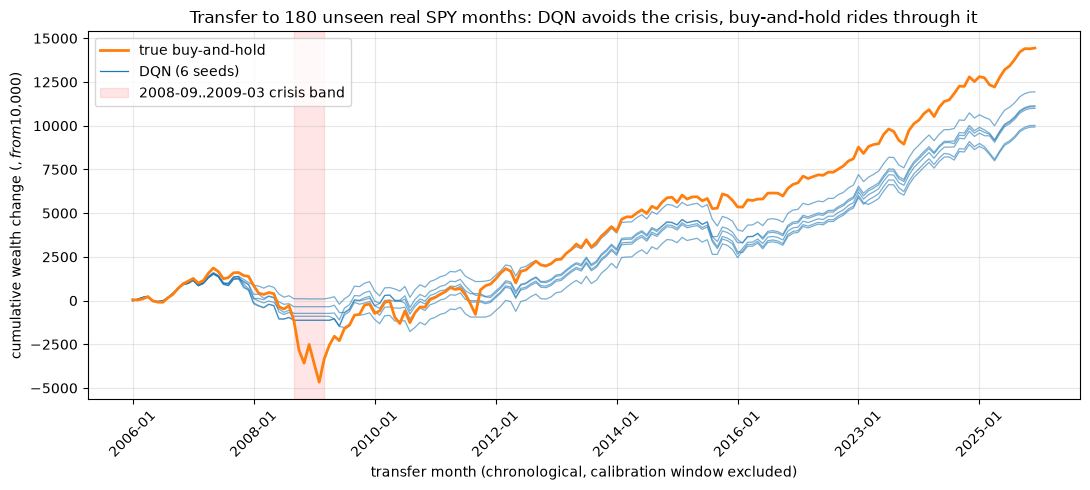

In [6]:
# Figure — cumulative transfer profit, DQN (per seed) vs buy-and-hold.
# The x axis is the 180 transfer months in order: 2006-01..2017-12,
# then 2023-01..2025-12 (2018-22 is excluded: the simulator was
# calibrated on it).
ids = [m["id"] for m in bah_months]
bah_cum = np.cumsum([m["delta_w"] for m in bah_months])

fig, ax = plt.subplots(figsize=(11, 5))
for s in main["results"]["dqn"]["per_seed"]:
    by_id = {m["id"]: m["delta_w"] for m in s["real_per_month"]}
    ax.plot(np.cumsum([by_id[i] for i in ids]), lw=0.9, alpha=0.6,
            color="tab:blue")
ax.plot(bah_cum, lw=2.0, color="tab:orange", label="true buy-and-hold")
ax.plot([], [], lw=0.9, color="tab:blue", label="DQN (6 seeds)")

lo = ids.index(CRISIS_FIRST)
hi = ids.index(CRISIS_LAST)
ax.axvspan(lo, hi, color="red", alpha=0.10,
           label="2008-09..2009-03 crisis band")

ticks = list(range(0, len(ids), 24))
ax.set_xticks(ticks)
ax.set_xticklabels([ids[t] for t in ticks], rotation=45)
ax.set_xlabel("transfer month (chronological, calibration window excluded)")
ax.set_ylabel("cumulative wealth change ($, from $10,000)")
ax.set_title("Transfer to 180 unseen real SPY months: "
             "DQN avoids the crisis, buy-and-hold rides through it")
ax.legend(loc="upper left")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### The first study, for contrast — the honest negative result

The dissertation reports the real-data pilot in full because its
failure motivates the main study's design. Sixty training months
against an 18,000-weight network is roughly 3 episodes per 1,000
weights; the network memorized rather than learned. The numbers below
are the committed first-study results.

In [7]:
# First study: 60 real train months (2018-22), 24 held-out test months.
first = json.loads((RESULTS / "final_results.json").read_text())
cell = first["results"]["S3_wealth"]   # the headline configuration

rows = []
for algo, block in cell["algos"].items():
    ac = block["across_seeds"]
    rows.append({
        "policy": algo.upper(),
        "mean dW ($/month)": round(ac["mean_delta_w"]["mean"], 2),
        "seed spread ($)": round(ac["mean_delta_w"]["spread"], 2),
        "Sharpe (seed mean)": round(ac["sharpe_monthly"]["mean"], 3),
    })
bah = cell["baselines"]["B1b_true_bah"]["summary"]
rows.append({
    "policy": "true buy-and-hold",
    "mean dW ($/month)": round(bah["mean_delta_w"], 2),
    "seed spread ($)": None,
    "Sharpe (seed mean)": round(bah["sharpe_monthly"], 3),
})
first_table = pd.DataFrame(rows).set_index("policy")

best_learner = max(cell["algos"].values(),
                   key=lambda b: b["across_seeds"]["mean_delta_w"]["mean"])
assert best_learner["across_seeds"]["mean_delta_w"]["mean"] < bah["mean_delta_w"]
print("CHECK PASSED: on real 2023-24 test months, no learner reached "
      f"buy-and-hold ({bah['mean_delta_w']:+.2f} $/month). "
      "This negative result is why the main study exists.")
first_table

CHECK PASSED: on real 2023-24 test months, no learner reached buy-and-hold (+180.25 $/month). This negative result is why the main study exists.


,mean dW ($/month),seed spread ($),Sharpe (seed mean)
policy,,,
REINFORCE,171.51,24.72,0.675
DQN,74.68,71.44,0.507
PPO,127.35,179.75,0.562
true buy-and-hold,180.25,NaN,0.638


### Post-viva extras (NOT in the submitted dissertation)

Two follow-up experiments answer questions raised at the viva
(14 September 2026). They use the same pipeline and are committed with
full provenance, but their numbers are not in the submitted PDF.

1. **Feature ablation** — "how do you know the volatility features
   drive the crisis avoidance?" Retrain DQN with the two volatility
   features removed.
2. **Tuned stop-loss baseline** — "would a simple stop-loss do the same
   job?" A fixed/trailing stop rule, tuned on the validation split
   only, then evaluated once on the held-out sets.

In [8]:
# Post-viva extra 1: feature ablation (volatility features removed).
abl = json.loads((RESULTS / "feature_ablation.json").read_text())
print("question:", abl["question"])
print("ablated features:", abl["ablated"])
print("crash window: Oct 2008; band:", abl["results"]["S3_full"]["crash"]["band"])
for name, c in abl["results"].items():
    cr = c["crash"]
    print(f"  {name:12s} Oct-2008 exposure={cr['exposure_month']:.3f} | "
          f"band exposure={cr['exposure_band']:.3f} | "
          f"band dW={cr['delta_band']:+8.2f}")
bc = abl["bah_crash"]
print(f"  {'bah':12s} Oct-2008 exposure={bc['exposure']:.3f} | "
      f"Oct-2008 dW={bc['delta_w']:+8.2f} | "
      f"band dW={bc['band_delta_w']:+8.2f}")

# Post-viva extra 2: the tuned stop-loss rule.
stop = json.loads((RESULTS / "stop_loss.json").read_text())
ch = stop["chosen"]
print(f"\nstop-loss selected on validation: {ch['variant']} at "
      f"{ch['threshold']:.0%}")
sl, bh, dq = stop["stop_loss"], stop["buy_and_hold"], stop["dqn_reference"]
comp = pd.DataFrame([
    {"strategy": f"stop-loss ({ch['variant']} {ch['threshold']:.0%})",
     "sim test dW ($/ep)": round(sl["sim_test"]["mean_delta_w"], 2),
     "transfer dW ($/mo)": round(sl["transfer"]["mean_delta_w"], 2),
     "transfer Sharpe": round(sl["transfer"]["sharpe_monthly"], 3),
     "crisis band dW ($)": round(sl["transfer_crisis_band"]["sum_delta_w"], 2)},
    {"strategy": "buy-and-hold",
     "sim test dW ($/ep)": round(bh["sim_test"]["mean_delta_w"], 2),
     "transfer dW ($/mo)": round(bh["transfer"]["mean_delta_w"], 2),
     "transfer Sharpe": round(bh["transfer"]["sharpe_monthly"], 3),
     "crisis band dW ($)": round(bh["transfer_crisis_band"]["sum_delta_w"], 2)},
    {"strategy": "DQN (6-seed mean)",
     "sim test dW ($/ep)": round(dq["sim_test_delta_w"]["mean"], 2),
     "transfer dW ($/mo)": round(dq["transfer_delta_w"]["mean"], 2),
     "transfer Sharpe": round(float(np.mean(dq["transfer_sharpe"])), 3),
     "crisis band dW ($)": round(dq["crisis_band_sum_delta_w"]["mean"], 2)},
]).set_index("strategy")
print("\nfinding: a stop-loss can only exit after losses begin; "
      "the agent learned not to enter.")
comp

question: Dr Nguyen, viva 14 Sep 2026: 'how do you know that?'
ablated features: ['vol_k', 'atr_norm']
crash window: Oct 2008; band: ['2008-09', '2008-10', '2008-11', '2008-12']
  S3_full      Oct-2008 exposure=0.000 | band exposure=0.022 | band dW= -180.34
  S3_novol     Oct-2008 exposure=0.012 | band exposure=0.304 | band dW= -711.80
  S3_account   Oct-2008 exposure=0.059 | band exposure=0.333 | band dW= -679.80
  bah          Oct-2008 exposure=0.754 | Oct-2008 dW=-1665.24 | band dW=-2223.35

stop-loss selected on validation: trailing at 5%

finding: a stop-loss can only exit after losses begin; the agent learned not to enter.


,sim test dW ($/ep),transfer dW ($/mo),transfer Sharpe,crisis band dW ($)
strategy,,,,
stop-loss (trailing 5%),59.46,45.26,0.118,-3105.35
buy-and-hold,-60.29,80.24,0.198,-3045.66
DQN (6-seed mean),126.94,60.28,0.224,-180.34


## Level 2 — recompute from the committed data

Level 1 trusted the result files. Level 2 does not: it re-runs the
package's 21 verification tests on your machine, then rebuilds the
deterministic baselines from the committed raw episode data with the
repository's own environment, and checks they match the committed
results exactly (not approximately).

The tests cover the accounting identity (cash + position = wealth at
every step, to the cent), the action mask, fee application, feature
construction, and the state-dependence probe.

In [9]:
# Run the package's verification tests (~1 minute).
proc = subprocess.run(
    [sys.executable, "-m", "pytest", "test_v2.py", "-q", "--no-header"],
    cwd=FINAL_V2, capture_output=True, text=True,
)
print(proc.stdout[-1500:])
if proc.returncode != 0:
    print(proc.stderr[-1500:])
assert proc.returncode == 0, "verification tests failed"
print("CHECK PASSED: all verification tests pass on this machine")

.....................                                                    [100%]
21 passed in 0.25s

CHECK PASSED: all verification tests pass on this machine


In [10]:
# Rebuild the deterministic baselines on the 180 real transfer months
# from the committed .npz data, using the repository's own environment,
# and compare against the committed result file. Deterministic policies
# must match EXACTLY; the random baseline is excluded (it draws fresh
# random actions).
sys.path.insert(0, str(FINAL_V2))
os.chdir(FINAL_V2)

import real_transfer
from features import resolve_rung
from harness import Config, run_baselines

transfer_meta, transfer_parts = real_transfer.load()
transfer_eps = real_transfer.all_episodes(transfer_parts)
print(f"loaded {len(transfer_eps)} transfer months from data/spy_transfer.npz")
print("calibration window excluded from transfer:",
      transfer_meta["excluded_calibration_window"])

cfg = Config("SIM_S3_wealth", resolve_rung("S3"), rung="S3")
fresh = run_baselines(cfg, transfer_eps)

DETERMINISTIC = ("B0_do_nothing", "B1a_slice_bah", "B1b_true_bah")
CHECK_KEYS = ("mean_delta_w", "std_delta_w", "sharpe_monthly",
              "mean_exposure", "mean_fees_paid")
for name in DETERMINISTIC:
    got = fresh[name]["summary"]
    want = main["baselines_real"][name]["summary"]
    for key in CHECK_KEYS:
        assert abs(got[key] - want[key]) < 1e-9, (name, key, got[key], want[key])
    print(f"  {name:16s} recomputed mean dW = {got['mean_delta_w']:+9.4f}  "
          "== committed value")

print("\nCHECK PASSED: environment + features + metrics rebuilt the "
      "committed baselines exactly from the committed raw data")

loaded 180 transfer months from data/spy_transfer.npz
calibration window excluded from transfer: ['2018-01', '2022-12']
  B0_do_nothing    recomputed mean dW =   +0.0000  == committed value
  B1a_slice_bah    recomputed mean dW =  +76.4795  == committed value
  B1b_true_bah     recomputed mean dW =  +80.2362  == committed value

CHECK PASSED: environment + features + metrics rebuilt the committed baselines exactly from the committed raw data


## Level 3 — full retrain

Training is seeded (seeds 42–47) and the data splits are committed
files, so a full rerun reproduces the study rather than resampling it.
Exact bit-level equality of trained weights across machines is not
guaranteed (PyTorch kernels differ across versions and hardware), but
the findings — DQN profitable and state-dependent on all seeds, the
crisis avoidance, the DQN-PPO gap — should reproduce. The committed
result files record the library versions used.

From the repository root:

```bash
python -m venv venv && source venv/bin/activate
pip install -r requirements.txt
cd experiments/final_v2

# 0. Verify the pipeline first
python -m pytest test_v2.py -q

# 1. Rebuild the datasets (optional - the .npz files are committed).
#    sim_data.py is deterministic; real_transfer.py downloads SPY daily
#    bars via yfinance, so tiny differences from vendor data revisions
#    are possible.
python sim_data.py
python real_transfer.py

# 2. Main study: 3 algorithms x 6 seeds x 300k steps
python run_sim.py            # -> results/sim_results.json

# 3. Supporting sweeps (slice size, risk penalty, regime cells, fees)
python run_sim_suite.py      # -> results/sim_{slice,lambda,cells,fees}.json

# 4. First study (real-data pilot)
python data.py               # rebuild data/spy_episodes.npz (yfinance)
python run_final.py          # -> results/final_results.json

# 5. Post-viva extras
python run_feature_ablation.py   # -> results/feature_ablation.json
python run_stop_loss.py          # -> results/stop_loss.json
```

The next cell prints the recorded wall-clock time per training run, so
you can budget before committing to a full rerun.

In [11]:
# Recorded wall-clock per training run (from the committed results,
# machine in the provenance block above).
for algo, block in main["results"].items():
    secs = [s["train"]["wall_seconds"] for s in block["per_seed"]]
    total = sum(secs)
    print(f"  {algo.upper():10s} {len(secs)} seeds x 300k steps: "
          f"{total/60:6.1f} min total ({np.mean(secs)/60:.1f} min/seed)")
grand = sum(s["train"]["wall_seconds"]
            for b in main["results"].values() for s in b["per_seed"])
print(f"\n  main study total training time: {grand/3600:.1f} hours")

  REINFORCE  6 seeds x 300k steps:    6.2 min total (1.0 min/seed)
  DQN        6 seeds x 300k steps:   22.0 min total (3.7 min/seed)
  PPO        6 seeds x 300k steps:   12.9 min total (2.2 min/seed)

  main study total training time: 0.7 hours


## Reproducibility statement

Mapped to the NeurIPS-style reproducibility checklist:

- **Code.** Public repository with per-module `STUDY:` headers; the
  file-by-file map is `docs/WORKSPACE_CATALOG.md`. The submitted
  version is frozen under the release tags (see GitHub Releases).
- **Data.** Source: SPY daily bars (auto-adjusted OHLCV) via
  `yfinance`; the exact episodes used are committed as `.npz` files
  under `experiments/final_v2/data/`, with metadata JSONs beside them.
  Train / validation / test splits are stored in those files, not
  drawn at runtime. The simulated-data generator is calibrated only on
  2018–22, and the real transfer set excludes that window.
- **Experiments.** Seeds fixed and listed (42–47) in every result
  file. Six seeds per configuration; seed spread reported next to
  every mean. Hyperparameters are in each result file's `config`
  block. Hardware and wall-clock are in each file's `provenance` and
  `train` blocks.
- **Reporting.** The first study's negative result is reported in
  full. Known limitations: six seeds is a small sample for significance
  claims; the simulator has three regimes; the state contains only
  price- and position-derived features. Post-viva follow-ups (feature
  ablation, stop-loss baseline) are labelled as outside the submitted
  PDF.

**Citation.** Akano, F. (2026). *Evaluating Reinforcement Learning
Algorithms for Portfolio Trading.* MSc dissertation, EEEM004,
University of Surrey. Repository:
[github.com/TheFinix13/dissertation-project](https://github.com/TheFinix13/dissertation-project).

Questions and issues: open a GitHub issue on the repository.